In [2]:
import os
import cartopy
import f90nml
import numpy as np
import xarray as xr
os.chdir("/home/philbou/projects/def-rfajber/philbou")
from wva_data.experiment.experiment_loader import ExperimentLoader
from wva_data.process_run.model_data_loader import MonthlyDataset
from datetime import datetime
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy
cartopy.config['pre_existing_data_dir'] = '/home/philbou/miniconda3/envs/pro_env/share/cartopy'
cartopy.config['data_dir'] = '/home/philbou/miniconda3/envs/pro_env/share/cartopy'
WVA_EXP = "/home/philbou/projects/def-rfajber/philbou/wva_exp"
NOTEBOOKS = "/home/philbou/projects/def-rfajber/philbou/wva_data/notebooks"

In [3]:
MonthlyDataset.vertical_integral

<function wva_data.process_run.model_data_loader.MonthlyDataset.vertical_integral(self, field, pfull, ps, dp)>

In [ ]:
exp_20m = ExperimentLoader("realistic_continents_T85_2moments_rrtm_qflux_0.1_0")
exp_5m = ExperimentLoader("realistic_continents_T85_2moments_rrtm_qflux")
exp_rt42 = ExperimentLoader("RT42_sst_0_bucket")

In [3]:
sst_amip_ = xr.open_dataset(f"{WVA_EXP}/input/sst_clim_amip(0).nc",decode_times=False)["sst_clim_amip(0)"]
land_mask_t85 = xr.open_dataset(f"{WVA_EXP}/input/era_land_t85.nc",decode_times=False)["land_mask"]
land_mask_t42 = xr.open_dataset(f"{WVA_EXP}/input/era_land_t42.nc",decode_times=False)["land_mask"]
surface_temperature_5m = exp_5m.load_diagnostic("t_surf", is_monthly=True)
surface_temperature_20m = exp_20m.load_diagnostic("t_surf", is_monthly=True)
surface_temperature_rt42 = exp_rt42.load_diagnostic("t_surf", is_monthly=True)

surface_temperature_5m.data = surface_temperature_5m.data.isel(time=slice(0, 12))
surface_temperature_20m.data = surface_temperature_20m.data.isel(time=slice(0, 12))
surface_temperature_rt42.data = surface_temperature_rt42.data.isel(time=slice(0, 12))

sst_amip_t85 = sst_amip_.interp(
                lat=surface_temperature_5m.data.lat,
                lon=surface_temperature_5m.data.lon,
                method='linear'  # or 'nearest', 'cubic'
            )
sst_amip_t42 = sst_amip_.interp(
                lat=surface_temperature_rt42.data.lat,
                lon=surface_temperature_rt42.data.lon,
                method='linear'  # or 'nearest', 'cubic'
            )

CWV_5m = exp_5m.load_diagnostic("column_integrated", is_monthly=True)
CWV_20m = exp_20m.load_diagnostic("t_surf", is_monthly=True)

In [ ]:
def bin_in_seasons(ds):
    ds_seasonal = ds.roll(time=1).coarsen(time=3).mean()
    return ds_seasonal
seasons = ['DJF', 'MAM', 'JJA', 'SON']

In [5]:
setattr(surface_temperature_5m, 'seasonal', None)
surface_temperature_5m.seasonal = bin_in_seasons(surface_temperature_5m.data)
setattr(surface_temperature_20m, 'seasonal', None)
surface_temperature_20m.seasonal = bin_in_seasons(surface_temperature_20m.data)

setattr(surface_temperature_rt42, 'seasonal', None)
surface_temperature_rt42.seasonal = bin_in_seasons(surface_temperature_rt42.data)
sst_amip_seasonal_t42 = bin_in_seasons(sst_amip_t42)
sst_amip_seasonal_t85 = bin_in_seasons(sst_amip_t85)


In [6]:
sea_mask_t42 = abs(land_mask_t42-1).values.astype(int)
sea_mask_t85 = abs(land_mask_t85-1).values.astype(int)

In [15]:
def plot_seasonal_sst_diff(sst1,sst2, seasons,title="",sea_mask=sea_mask_t85):
    sst =  (sst1 - sst2)
    fig,ax = plt.subplots(2, 2, figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    sst_levels = np.linspace(-20,20,21)
    k=0
    for i in range(2):
        for j in range(2): 
            cur_sst = sst.isel(time=k).values *sea_mask
            
            cb = ax[i,j].contourf(sst.lon, sst.lat, cur_sst, transform=ccrs.PlateCarree(), cmap='coolwarm',levels = sst_levels,extend='both')        
            plt.colorbar(cb, ax=ax[i,j], orientation='vertical', label='$\\Delta$SST (K)',shrink = 0.8)
            ax[i,j].set_title(f"Seasonal Mean SST - {seasons[k]}")
            ax[i,j].coastlines()
            k+=1
    fig.suptitle(f"Absolute Difference in Seasonal Mean SST - {title}", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{NOTEBOOKS}/plots/seasonal_sst_diff_{title}.png",dpi = 300)

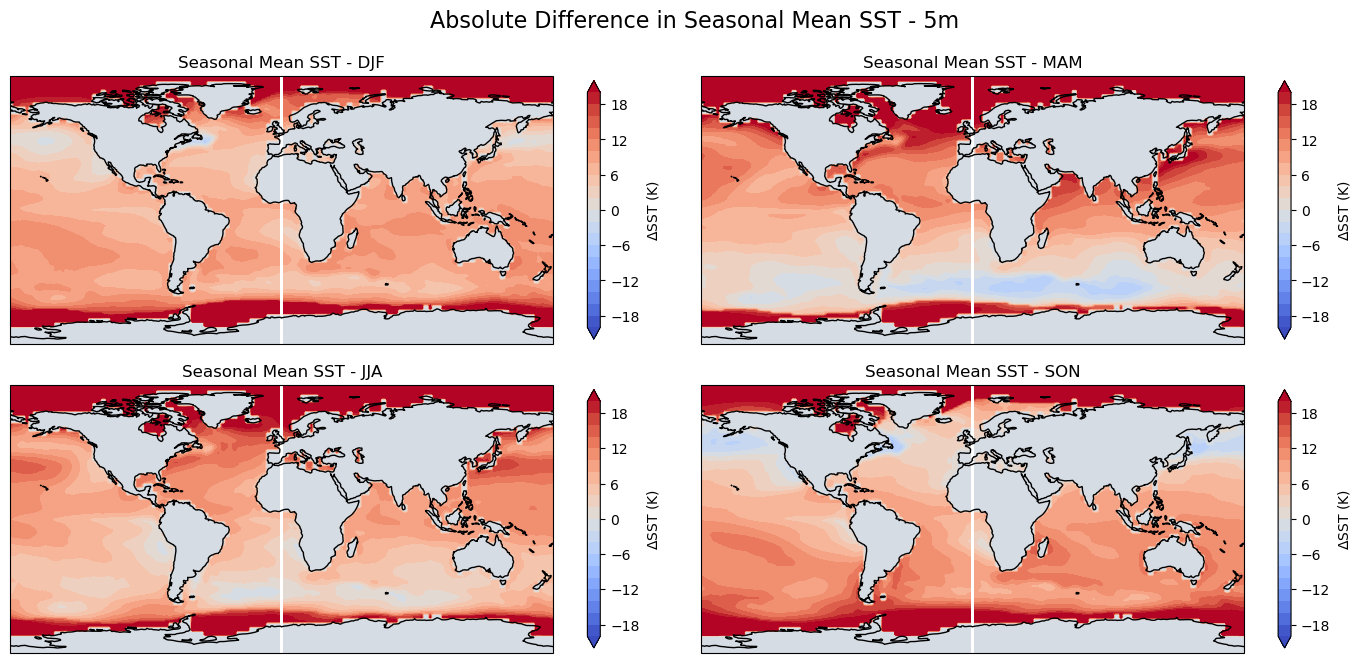

In [16]:

plot_seasonal_sst_diff(sst_amip_seasonal_t85, surface_temperature_5m.seasonal, seasons,title="5m")


The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


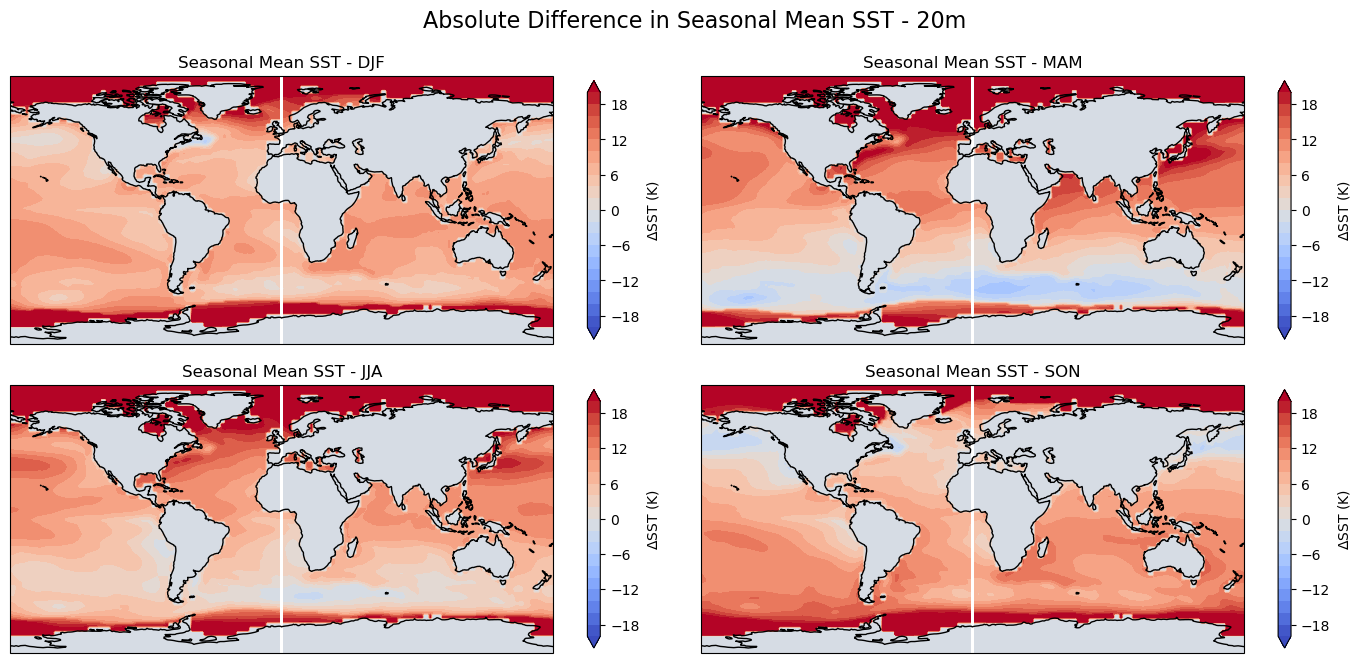

In [17]:
plot_seasonal_sst_diff(sst_amip_seasonal_t85, surface_temperature_20m.seasonal, seasons,title="20m")

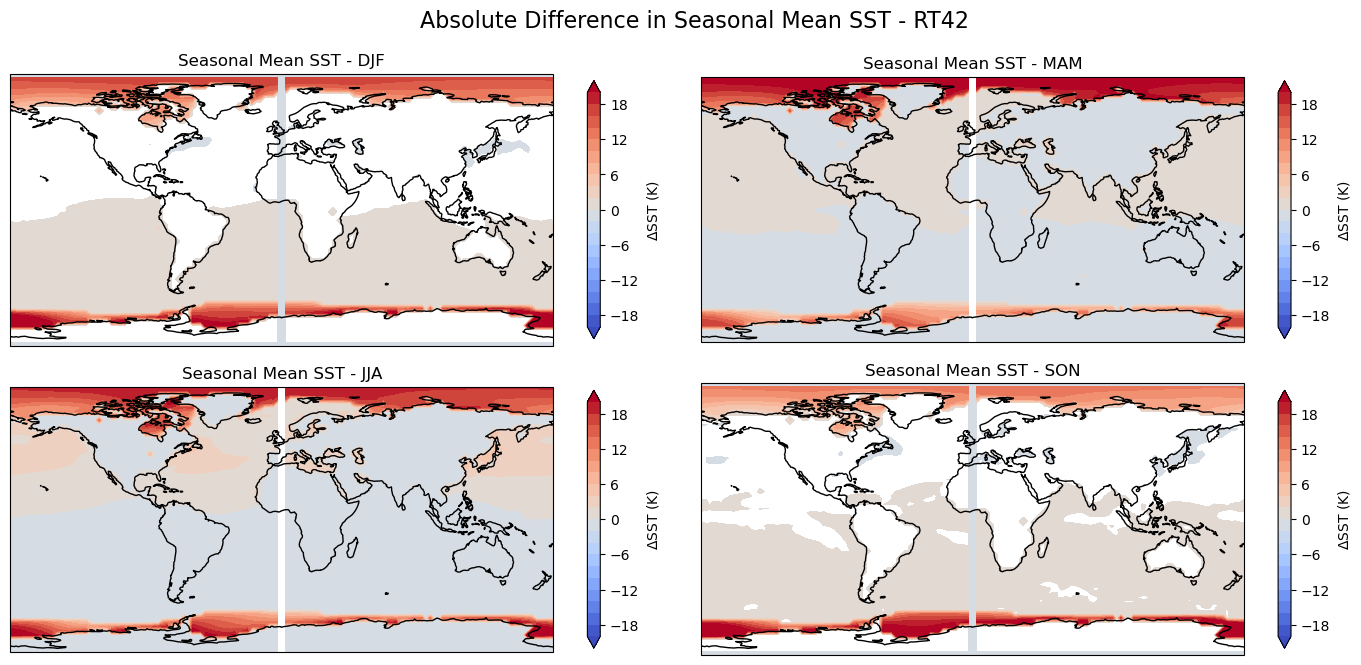

In [18]:
plot_seasonal_sst_diff(sst_amip_seasonal_t42, surface_temperature_rt42.seasonal, seasons,title="RT42",sea_mask=sea_mask_t42)